In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [3]:
# прочитаем наши данные из файла users и запишем в переменную
users = pd.read_csv('C:/Users/majkl/WorkSpace/Analysis_user_in_app/users.csv')
# выведем инофрмацию о датафрейме
users.info()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1000 non-null   object
 1   registration_date  1000 non-null   object
 2   country            1000 non-null   object
 3   device             1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


,user_id,registration_date,country,device
0,user_0,2024-02-21,France,iPhone
1,user_1,2024-01-15,USA,Android
2,user_2,2024-03-12,France,Android
3,user_3,2024-03-01,India,Android
4,user_4,2024-01-21,France,iPhone


In [4]:
# прочитаем наши данные из файла events и запишем в переменную
events = pd.read_csv('C:/Users/majkl/WorkSpace/Analysis_user_in_app/events.csv')
# выведем инофрмацию о датафрейме
events.info()
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27297 entries, 0 to 27296
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          27297 non-null  object
 1   event_timestamp  27297 non-null  object
 2   event_name       27297 non-null  object
dtypes: object(3)
memory usage: 639.9+ KB


,user_id,event_timestamp,event_name
0,user_0,2024-03-04 16:47:32,app_launch
1,user_0,2024-03-04 16:49:49,search
2,user_0,2024-03-04 16:51:51,view_product
3,user_0,2024-03-04 16:52:42,logout
4,user_0,2024-03-04 16:52:52,view_product


In [5]:
# поиск дублей записей
print(users.isnull().sum())
print(events.isnull().sum())

user_id              0
registration_date    0
country              0
device               0
dtype: int64
user_id            0
event_timestamp    0
event_name         0
dtype: int64


In [6]:
# Переводим timestamp в дату
events['event_date'] = pd.to_datetime(events['event_timestamp']).dt.date

##### Дублей не обнаружено, записи в нужном виде для анализа, можно перейти к нахождению основных метрик

### Расчет ключевых метрик

In [8]:
# Находим максимальную дату 
max_event_date = events['event_date'].max()
print(f"Максимальная дата в данных: {max_event_date}")

# DAU за последний месяц
last_month_start = max_event_date - timedelta(days=30)
last_month = events[events['event_date'] >= last_month_start]
dau = last_month.groupby('event_date')['user_id'].nunique()
print("Средний DAU за последний месяц:", round(dau.mean(), 2))
print("\n")

# WAU и MAU (приближенно)
print("Пример WAU (за последнюю неделю):")
last_week_start = max_event_date - timedelta(days=7)
last_week = events[events['event_date'] >= last_week_start]
wau = last_week['user_id'].nunique()
print("WAU:", wau)

print("Пример MAU (за последние 30 дней):")
mau = last_month['user_id'].nunique()
print("MAU:", mau)

# Считаем Sticky Factor (DAU/MAU) - "липкость" приложения
sticky_factor = dau.mean() / mau
print("Sticky Factor (DAU/MAU):", round(sticky_factor, 2))
print("\n")

Максимальная дата в данных: 2024-06-27
Средний DAU за последний месяц: 9.29


Пример WAU (за последнюю неделю):
WAU: 21
Пример MAU (за последние 30 дней):
MAU: 167
Sticky Factor (DAU/MAU): 0.06




### Конверсия в покупку

Общая конверсия в покупку: 87.90%


Пользователей на шаге 'app_launch': 993
Пользователей на шаге 'search': 972
Пользователей на шаге 'view_product': 965
Пользователей на шаге 'add_to_cart': 940
Пользователей на шаге 'purchase': 879


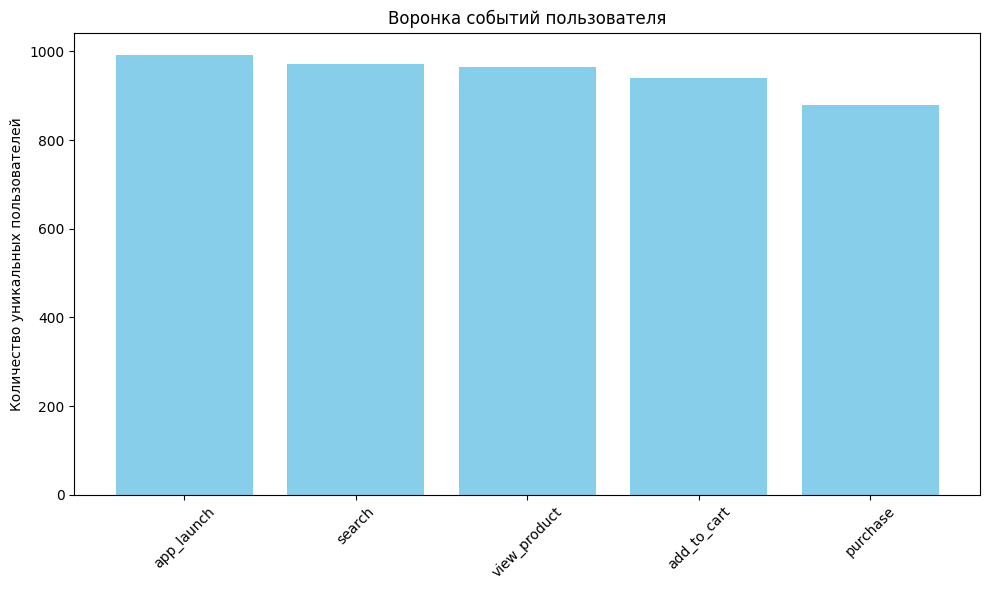

Конверсия из 'app_launch' в 'search': 97.89%
Конверсия из 'search' в 'view_product': 99.28%
Конверсия из 'view_product' в 'add_to_cart': 97.41%
Конверсия из 'add_to_cart' в 'purchase': 93.51%


In [9]:
# Считаем, сколько пользователей совершило хотя бы одну покупку
users_with_purchase = events[events['event_name'] == 'purchase']['user_id'].nunique()
total_users = events['user_id'].nunique()

conversion_rate = users_with_purchase / total_users * 100
print(f"Общая конверсия в покупку: {conversion_rate:.2f}%")
print("\n")

# Строим воронку событий: app_launch -> search -> view_product -> add_to_cart -> purchase
funnel_steps = ['app_launch', 'search', 'view_product', 'add_to_cart', 'purchase']
funnel_data = []

for step in funnel_steps:
    unique_users = events[events['event_name'] == step]['user_id'].nunique()
    funnel_data.append(unique_users)
    print(f"Пользователей на шаге '{step}': {unique_users}")

# Визуализируем воронку
plt.figure(figsize=(10, 6))
plt.bar(funnel_steps, funnel_data, color='skyblue')
plt.title('Воронка событий пользователя')
plt.ylabel('Количество уникальных пользователей')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Считаем конверсию между шагами
for i in range(1, len(funnel_data)):
    conv = funnel_data[i] / funnel_data[i-1] * 100
    print(f"Конверсия из '{funnel_steps[i-1]}' в '{funnel_steps[i]}': {conv:.2f}%")

### Анализ удержания (Retention)

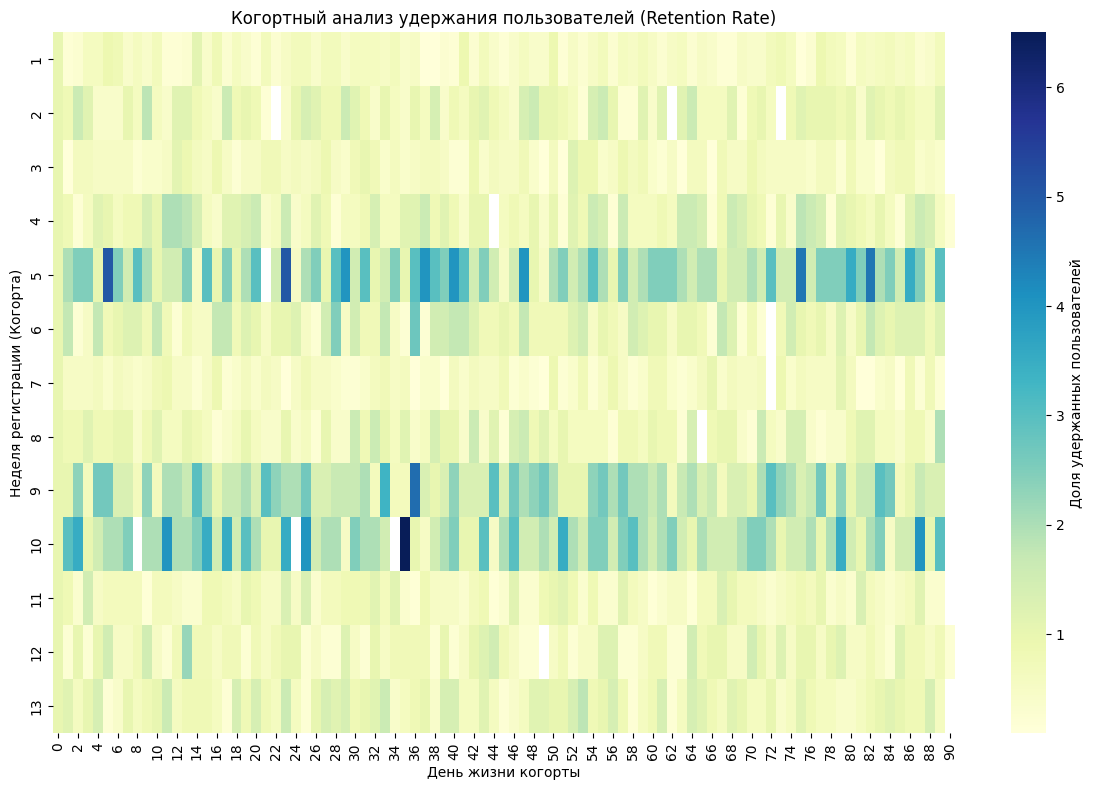

In [13]:
# Создаем таблицу, где для каждого пользователя есть дата регистрации и дата его активностей
user_first_date = events.groupby('user_id')['event_date'].min().reset_index()
user_first_date.columns = ['user_id', 'first_date']

# Добавляем дату регистрации из таблицы users
events_with_reg = events.merge(users[['user_id', 'registration_date']], on='user_id')

# Преобразуем обе даты в pandas Timestamp
events_with_reg['event_date'] = pd.to_datetime(events_with_reg['event_date'])
events_with_reg['registration_date'] = pd.to_datetime(events_with_reg['registration_date'])

# Считаем "возраст" когорты (день относительно даты регистрации)
events_with_reg['cohort_day'] = (events_with_reg['event_date'] - events_with_reg['registration_date']).dt.days

# Группируем по когорте (неделя регистрации)
events_with_reg['cohort_week'] = events_with_reg['registration_date'].dt.isocalendar().week

# Альтернативный вариант для недели регистрации (если предыдущий не работает):
# events_with_reg['cohort_week'] = events_with_reg['registration_date'].dt.strftime('%Y-%W')

cohort_data = events_with_reg.groupby(['cohort_week', 'cohort_day'])['user_id'].nunique().reset_index()

# Создаем таблицу удержания (Retention Table)
cohort_pivot = cohort_data.pivot_table(index='cohort_week', columns='cohort_day', values='user_id')

# Пересчитываем в проценты от размера когорты (день 0)
cohort_size = cohort_pivot.iloc[:, 0]
retention_table = cohort_pivot.divide(cohort_size, axis=0)

# Визуализируем тепловую карту удержания
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(retention_table, annot=False, fmt='.0%', cmap='YlGnBu', cbar_kws={'label': 'Доля удержанных пользователей'})
plt.title('Когортный анализ удержания пользователей (Retention Rate)')
plt.ylabel('Неделя регистрации (Когорта)')
plt.xlabel('День жизни когорты')
plt.tight_layout()
plt.show()


### Анализ по сегментам

Конверсия в покупку по странам:
country
India      90.05
Germany    89.01
USA        88.89
UK         88.06
France     81.63
Name: user_id, dtype: float64




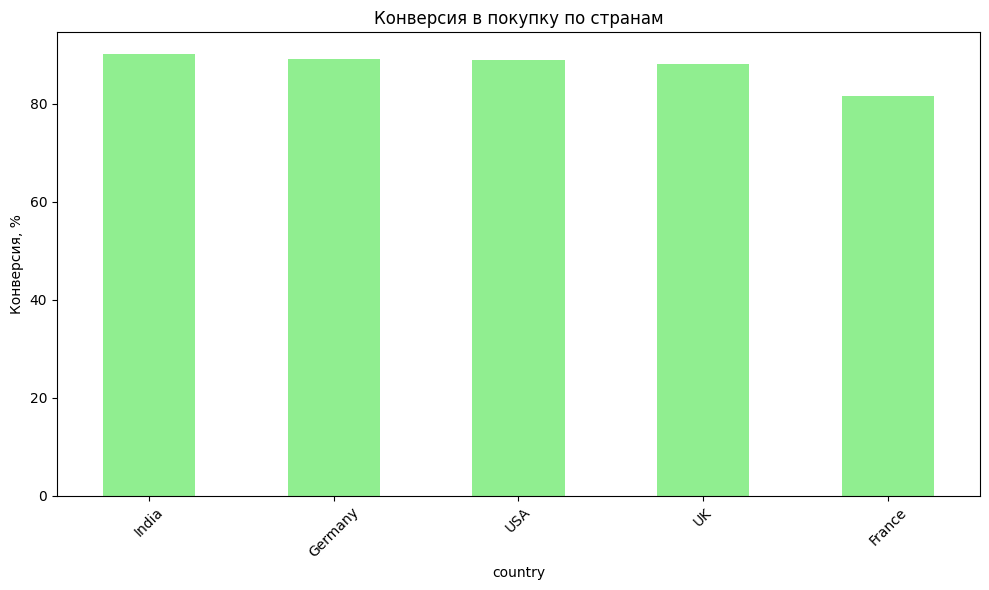

Конверсия в покупку по устройствам:
device
iPhone     89.09
Android    86.14
Name: user_id, dtype: float64


In [14]:
# Объединяем события с данными о пользователях для сегментации
events_segmented = events.merge(users, on='user_id')

# Конверсия в покупку по странам
purchase_by_country = events_segmented[events_segmented['event_name'] == 'purchase'].groupby('country')['user_id'].nunique()
total_users_by_country = events_segmented.groupby('country')['user_id'].nunique()
conversion_by_country = (purchase_by_country / total_users_by_country * 100).round(2)

print("Конверсия в покупку по странам:")
print(conversion_by_country.sort_values(ascending=False))
print("\n")

# Визуализируем
conversion_by_country.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='lightgreen')
plt.title('Конверсия в покупку по странам')
plt.ylabel('Конверсия, %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Анализ по устройствам
purchase_by_device = events_segmented[events_segmented['event_name'] == 'purchase'].groupby('device')['user_id'].nunique()
total_users_by_device = events_segmented.groupby('device')['user_id'].nunique()
conversion_by_device = (purchase_by_device / total_users_by_device * 100).round(2)

print("Конверсия в покупку по устройствам:")
print(conversion_by_device.sort_values(ascending=False))

### Выводы

Общая активность: В приложении в среднем 9.29 DAU. Sticky Factor составляет 0.06, что говорит о плохой привычке пользователей возвращаться в приложение.

Воронка и конверсия: Общая конверсия в покупку — 87.90%. Главная потеря пользователей происходит на шаге Добавления карты -> Покупка, где отваливается 10% пользователей. Рекомендация: Изучить юзабилити этого экрана.

Сегментация: Пользователи из India конвертируются на 7% лучше, чем пользователи из France. Рекомендация: Для France провести A/B тест с локализованным контентом. Пользователи iPhone показывают более высокую лояльность.